<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

# Credit scoring on SageMaker — champion vs challenger

*Draft notebook — a narrative layer over the tested `src/` model classes, not a re-implementation. The scorecard (`ScorecardPredictor`) and challenger (`ChallengerModel`) are imported from the chapter's code; here they are trained and compared in-memory. On AWS the same classes train as SageMaker jobs, register to MLflow, and deploy behind an endpoint — see `aws/`.*

*Training and comparison run locally either way; the **`MODE`** parameter only changes how the final application is scored — in-process, or through the challenger's deployed SageMaker endpoint.*

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-cog" style="color:#18ab4b"></i>&nbsp; Parameters</h2>

Tagged `parameters`: `papermill champion_challenger.ipynb out.ipynb -p MODE aws` (needs the challenger endpoint up: `make -C aws deploy`).

In [1]:
# parameters
MODE = "local"  # "local": score in-process  |  "aws": invoke the deployed challenger endpoint
REGION = "us-east-1"
CHALLENGER_ENDPOINT = "ch02-challenger-byoc"

In [2]:
import sys
import json
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# the tested model classes, imported not copied
sys.path.insert(0, "../src/scorecard")
sys.path.insert(0, "../src/challenger")
from scorecard_model import ScorecardPredictor
from challenger_model import ChallengerModel

spec = json.load(open("../data/split/feature_spec.json"))
target, features = (
    spec["target"],
    spec["numeric_features"] + spec["categorical_features"],
)
train = pd.read_csv("../data/split/train.csv")
test = pd.read_csv("../data/split/test.csv")
f"{len(train):,} train / {len(test):,} test rows, default rate {train[target].mean():.1%}"

'15,000 train / 5,000 test rows, default rate 21.2%'

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-database" style="color:#18ab4b"></i>&nbsp; The applications</h2>

In [3]:
train.head()

,age,annual_income,debt_to_income,bureau_score,credit_utilization,employment_length_years,loan_amount,home_ownership,loan_purpose,employment_status,default
0,72,35800.0,5.9,631,15.7,6.7,55300.0,OWN,debt_consolidation,self_employed,0
1,54,32000.0,32.1,716,11.1,2.8,11100.0,OWN,home_improvement,employed,0
2,69,35000.0,10.9,629,42.4,5.7,14100.0,MORTGAGE,debt_consolidation,employed,0
3,52,29200.0,27.3,623,12.2,1.4,9000.0,RENT,debt_consolidation,employed,0
4,62,23600.0,6.9,638,25.3,9.2,7700.0,RENT,car,employed,0


In [4]:
pd.Series(spec["monotone_constraints"]).rename("monotone_constraint").to_frame()

,monotone_constraint
annual_income,-1
debt_to_income,1
bureau_score,-1
credit_utilization,1
employment_length_years,-1
loan_amount,1
age,0
home_ownership,0
loan_purpose,0
employment_status,0


<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-book" style="color:#18ab4b"></i>&nbsp; Champion — the WOE scorecard</h2>

The incumbent: Weight-of-Evidence binning (monotone on the constrained numerics) into a logistic regression. The monotone binning **is** the business rule, satisfied by construction.

In [5]:
from fastwoe import FastWoe
from sklearn.linear_model import LogisticRegression

monotone = spec["monotone_constraints"]
woe = FastWoe(monotonic_cst=monotone)
Xw = woe.fit_transform(train[features], train[target])
lr = LogisticRegression(C=1.0, max_iter=1000).fit(Xw, train[target])
champion = ScorecardPredictor(woe, lr, spec)  # the tested serving class
"champion fitted"

'champion fitted'

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-brain" style="color:#18ab4b"></i>&nbsp; Challenger — monotone XGBoost</h2>

The challenger: gradient-boosted trees under the **same** signed monotone constraints, so it can only win on fit, not by breaking the rule.

In [6]:
import xgboost as xgb

Xc = train[features].copy()
for col in spec["categorical_features"]:
    Xc[col] = Xc[col].astype("category")

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    enable_categorical=True,
    eval_metric="auc",
    monotone_constraints={f: monotone[f] for f in features},
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)
xgb_model.fit(Xc, train[target])
challenger = ChallengerModel(xgb_model, spec)  # the tested serving class
"challenger fitted"

'challenger fitted'

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-chart-bar" style="color:#18ab4b"></i>&nbsp; Metrics — the numbers a credit team reads first</h2>

In [7]:
from sklearn.metrics import roc_auc_score, roc_curve


def metrics(y_true, p):
    """AUC, Gini, KS -- the same three src/steps train.py reports."""
    auc = roc_auc_score(y_true, p)
    fpr, tpr, _ = roc_curve(y_true, p)
    return {"auc": auc, "gini": 2 * auc - 1, "ks": float(max(tpr - fpr))}


yt = test[target]
p_champ = champion.predict_proba(test)
p_chall = challenger.predict_proba(test)
pd.DataFrame(
    {
        "champion (scorecard)": metrics(yt, p_champ),
        "challenger (xgboost)": metrics(yt, p_chall),
    }
).round(4)

,champion (scorecard),challenger (xgboost)
auc,0.8625,0.8826
gini,0.7250,0.7652
ks,0.5681,0.6028


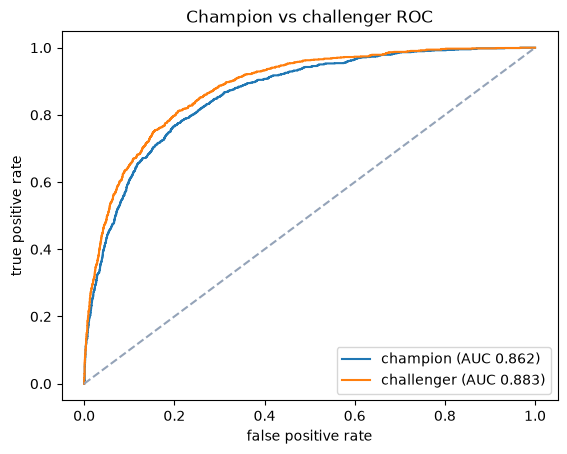

In [8]:
for name, p in [("champion", p_champ), ("challenger", p_chall)]:
    fpr, tpr, _ = roc_curve(yt, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(yt, p):.3f})")
plt.plot([0, 1], [0, 1], "--", color="#94a3b8")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Champion vs challenger ROC")
plt.legend()
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-play-circle" style="color:#18ab4b"></i>&nbsp; Score an application</h2>

The champion scores in-process (the incumbent stays in-house). The challenger scores in-process in `local` mode, or through its deployed endpoint in `aws` mode — the same call, confirming the served model matches.

In [9]:
applicant = test[features].iloc[[0]]
champ_pd = champion.predict_proba(applicant)[0]

if MODE == "local":
    chall_pd = challenger.predict_proba(applicant)[0]
else:
    import boto3

    _runtime = boto3.client("sagemaker-runtime", region_name=REGION)
    resp = _runtime.invoke_endpoint(
        EndpointName=CHALLENGER_ENDPOINT,
        ContentType="application/json",
        Body=applicant.to_json(orient="records"),
    )
    chall_pd = json.loads(resp["Body"].read())["pd"][0]

display(applicant)
f"[{MODE}] champion pd {champ_pd:.4f}  |  challenger pd {chall_pd:.4f}"

,annual_income,debt_to_income,bureau_score,credit_utilization,employment_length_years,loan_amount,age,home_ownership,loan_purpose,employment_status
0,31100.0,13.0,711,29.9,8.3,3400.0,36,MORTGAGE,medical,employed


'[local] champion pd 0.0064  |  challenger pd 0.0166'

---
*On AWS these two classes train as SageMaker training jobs, register to the MLflow model registry, and deploy behind a serverless endpoint (`aws/`, `make train` / `make deploy`). This notebook is the narrative view of the same model code.*